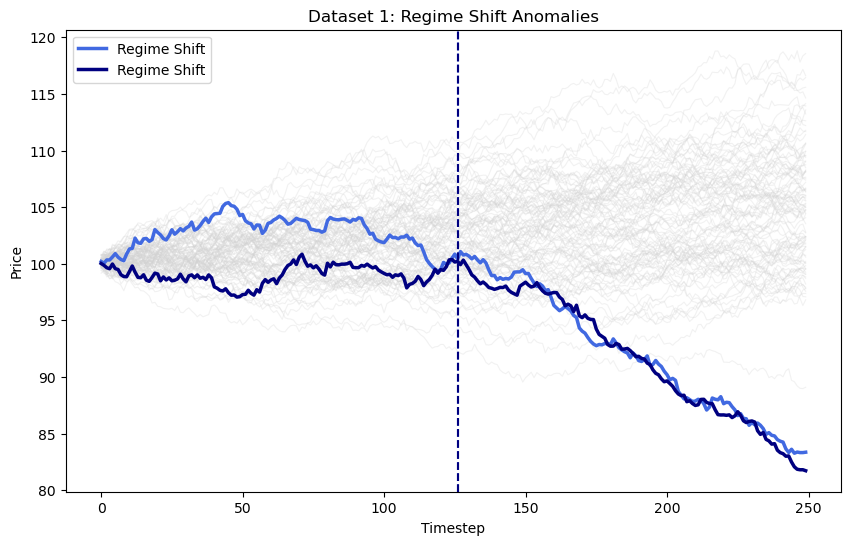

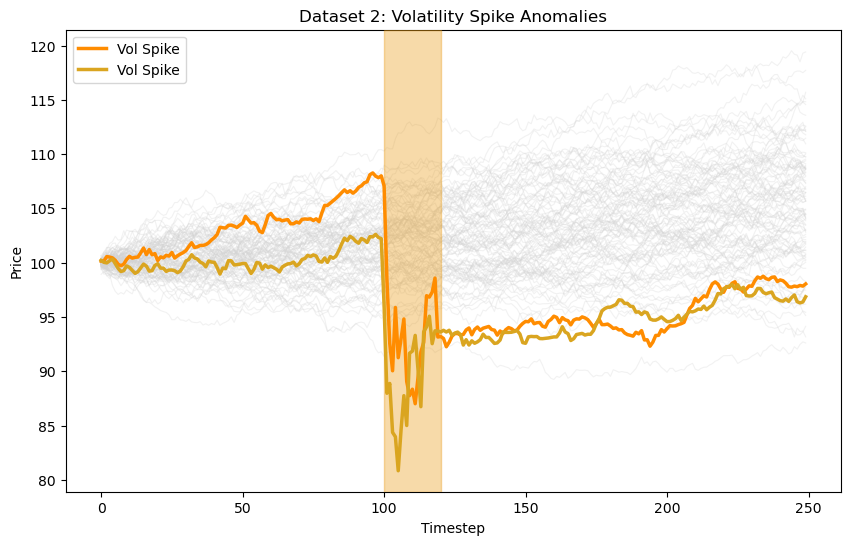

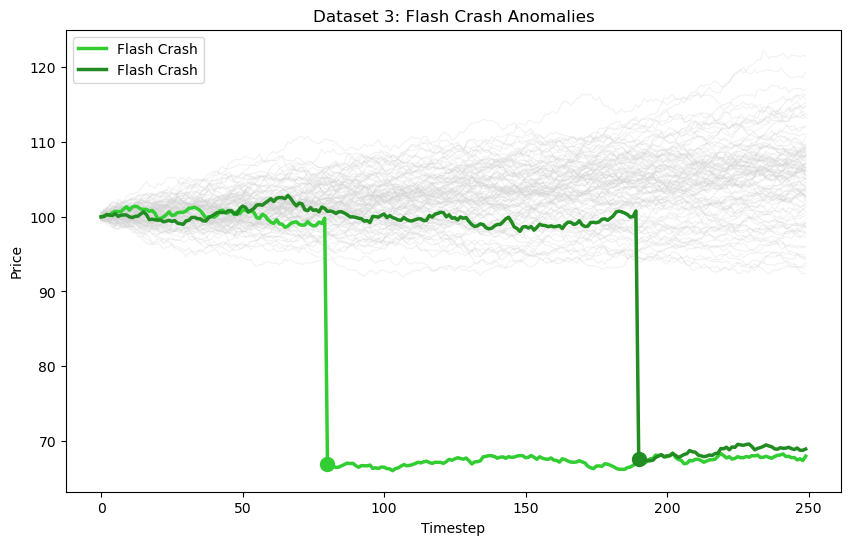

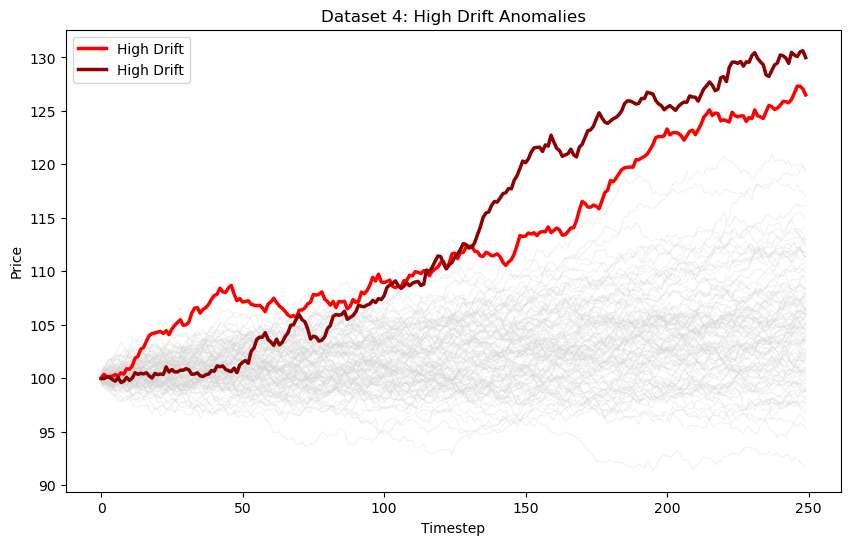

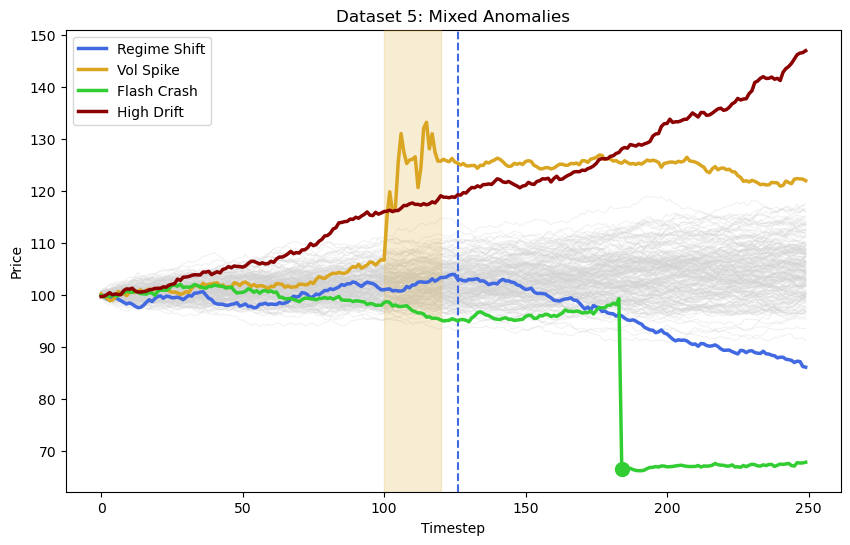

In [25]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# -----------------------------
# Parameters
# -----------------------------
T = 250 #T staat hier voor het aantal stappen, dus tijdreeksen van 1 jaar "N"
dt = 1/250 
S0 = 100 #initiele waare
mu = 0.05 #gemiddeld
sigma = 0.05 #gemiddeld laag maar laat juist afwijkingen beter zien


# -----------------------------
# GBM generator
# -----------------------------
def generate_gbm(mu, sigma):

    eps = np.random.normal(0,1,T) #een array van T standaard normaal verdeelde random variabelen (eps ~ N(0,1))
    #die de willekeurige beweging van de prijs simuleren

    log_returns = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*eps 

    prices = S0*np.exp(np.cumsum(log_returns)) #cumulatieve som van log-returns 
    #wat overeenkomt met de log van de prijs
    #exp zet dit terug naar gewone prijzen

    return prices, log_returns #zowel S(t) als logS(t) bepaald voor elke t


# -----------------------------
# Anomaly generators
# -----------------------------
def regime_shift():

    prices, returns = generate_gbm(mu,sigma)

    break_point = 126 #tijdstip regime shift
    mu_new = -0.40 #van 0.05 naar -0.40

    eps = np.random.normal(0,1,T-break_point)

    returns[break_point:] = (mu_new-0.5*sigma**2)*dt + sigma*np.sqrt(dt)*eps

    prices = S0*np.exp(np.cumsum(returns))

    info = {"type":"regime_shift","break":break_point}

    return prices, info


def volatility_spike():

    prices, returns = generate_gbm(mu,sigma)

    spike_start = 100
    spike_length = 20
    sigma_spike = 0.8

    eps = np.random.normal(0,1,spike_length)

    returns[spike_start:spike_start+spike_length] = (
        (mu-0.5*sigma_spike**2)*dt +
        sigma_spike*np.sqrt(dt)*eps
    )

    prices = S0*np.exp(np.cumsum(returns))

    info = {
        "type":"vol_spike",
        "start":spike_start,
        "end":spike_start+spike_length
    }

    return prices, info


def flash_crash():

    prices, returns = generate_gbm(mu,sigma)

    crash_day = np.random.randint(80,200)

    returns[crash_day] = -0.40

    prices = S0*np.exp(np.cumsum(returns))

    info = {"type":"flash_crash","day":crash_day}

    return prices, info


def high_drift():

    mu_high = 0.30

    prices,_ = generate_gbm(mu_high,sigma)

    info = {"type":"high_drift"}

    return prices, info


# -----------------------------
# Dataset generator
# -----------------------------
def create_dataset(n_paths, anomaly_func=None, n_anomalies=0):

    prices_list = []
    labels = []
    anomaly_indices = []
    anomaly_info = {}

    for i in range(n_paths):

        prices,_ = generate_gbm(mu,sigma)

        prices_list.append(prices)
        labels.append(0)

    if anomaly_func is not None:

        anomaly_indices = np.random.choice(n_paths,n_anomalies,replace=False)

        for idx in anomaly_indices:

            prices,info = anomaly_func()

            prices_list[idx] = prices
            labels[idx] = 1

            anomaly_info[idx] = info

    return np.array(prices_list),np.array(labels),anomaly_indices,anomaly_info


# -----------------------------
# Create datasets
# -----------------------------
datasets = {}

datasets["regime_shift_set"] = create_dataset(100,regime_shift,2)
datasets["volatility_spike_set"] = create_dataset(100,volatility_spike,2)
datasets["flash_crash_set"] = create_dataset(100,flash_crash,2)
datasets["high_drift_set"] = create_dataset(100,high_drift,2)


# -----------------------------
# Mixed dataset
# -----------------------------
prices_list=[]
labels=[]
anomaly_info={}
anomaly_indices=[]

for i in range(200):

    prices,_ = generate_gbm(mu,sigma)

    prices_list.append(prices)
    labels.append(0)

anomaly_functions=[regime_shift,volatility_spike,flash_crash,high_drift]

indices=np.random.choice(200,4,replace=False)

for idx,func in zip(indices,anomaly_functions):

    prices,info = func()

    prices_list[idx]=prices
    labels[idx]=1

    anomaly_info[idx]=info
    anomaly_indices.append(idx)

datasets["mixed_anomaly_set"] = (
    np.array(prices_list),
    np.array(labels),
    anomaly_indices,
    anomaly_info
)


# -----------------------------
# Color palettes
# -----------------------------
colors = {
    "regime_shift":["royalblue","navy"],
    "vol_spike":["darkorange","goldenrod"],
    "flash_crash":["limegreen","forestgreen"],
    "high_drift":["red","darkred"]
}


# -----------------------------
# Plot function
# -----------------------------
def plot_anomalies(prices, labels, anomaly_indices, anomaly_info, title):

    plt.figure(figsize=(10,6))

    # -----------------------------
    # 1. Plot normale paden (achtergrond)
    # -----------------------------
    for i in range(len(prices)):
        if labels[i] == 0:
            plt.plot(
                prices[i],
                color="lightgray",
                alpha=0.3,
                linewidth=0.8,
                zorder=1
            )

    # -----------------------------
    # 2. Plot anomalies (foreground)
    # -----------------------------
    for i, idx in enumerate(anomaly_indices):

        path = prices[idx]
        info = anomaly_info[idx]

        anomaly_type = info["type"]
        color = colors[anomaly_type][i % 2]
        label = anomaly_type.replace("_"," ").title()

        plt.plot(
            path,
            linewidth=2.5,
            color=color,
            label=label,
            zorder=10
        )

        # markers
        if anomaly_type == "regime_shift":

            plt.axvline(
                info["break"],
                linestyle="--",
                color=color,
                zorder=10
            )

        elif anomaly_type == "vol_spike":

            plt.axvspan(
                info["start"],
                info["end"],
                alpha=0.2,
                color=color,
                zorder=5
            )

        elif anomaly_type == "flash_crash":

            day = info["day"]

            plt.scatter(
                day,
                path[day],
                color=color,
                s=100,
                zorder=15
            )

    plt.title(title)
    plt.xlabel("Timestep")
    plt.ylabel("Price")
    plt.legend()
    plt.show()


# -----------------------------
# Create plots
# -----------------------------
prices,labels,idx,info = datasets["regime_shift_set"]
plot_anomalies(prices,labels,idx,info,"Dataset 1: Regime Shift Anomalies")

prices,labels,idx,info = datasets["volatility_spike_set"]
plot_anomalies(prices,labels,idx,info,"Dataset 2: Volatility Spike Anomalies")

prices,labels,idx,info = datasets["flash_crash_set"]
plot_anomalies(prices,labels,idx,info,"Dataset 3: Flash Crash Anomalies")

prices,labels,idx,info = datasets["high_drift_set"]
plot_anomalies(prices,labels,idx,info,"Dataset 4: High Drift Anomalies")

prices,labels,idx,info = datasets["mixed_anomaly_set"]
plot_anomalies(prices,labels,idx,info,"Dataset 5: Mixed Anomalies")

In [19]:
# -----------------------------
# GBM VALIDATION TABLE
# -----------------------------

import numpy as np
import pandas as pd

# Simulation sizes
sim_sizes = [20, 200, 2000, 20000]

# Theoretical values at time T
t = T * dt
theoretical_mean = S0 * np.exp(mu * t)
theoretical_var = (S0**2) * np.exp(2*mu*t) * (np.exp(sigma**2*t) - 1)

results = []

for n in sim_sizes:
    
    final_prices = []
    
    for i in range(n):
        prices, _ = generate_gbm(mu, sigma)
        final_prices.append(prices[-1])
    
    final_prices = np.array(final_prices)
    
    empirical_mean = np.mean(final_prices)
    empirical_var = np.var(final_prices, ddof=1)  # sample variance
    
    results.append([
        n,
        empirical_mean,
        theoretical_mean,
        empirical_var,
        theoretical_var
    ])

# Tabel maken
df_results = pd.DataFrame(
    results,
    columns=[
        "Number of Simulations",
        "Empirical E[S(T)]",
        "Theoretical E[S(T)]",
        "Empirical Var[S(T)]",
        "Theoretical Var[S(T)]"
    ]
)

print("\nValidation of GBM Simulation:")
print(df_results)


Validation of GBM Simulation:
   Number of Simulations  Empirical E[S(T)]  Theoretical E[S(T)]  \
0                     20         105.008030            105.12711   
1                    200         104.776444            105.12711   
2                   2000         105.050573            105.12711   
3                  20000         105.115149            105.12711   

   Empirical Var[S(T)]  Theoretical Var[S(T)]  
0            21.184289              27.663838  
1            24.532886              27.663838  
2            28.570156              27.663838  
3            27.185861              27.663838  


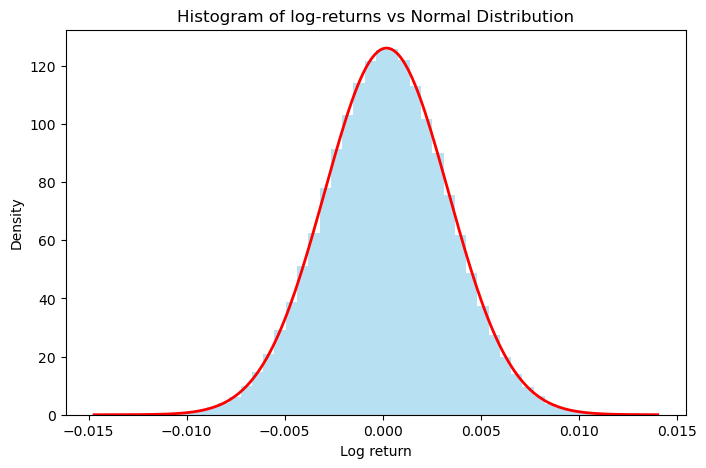

In [20]:
# -----------------------------
# Histogram log-returns
# -----------------------------

from scipy import stats

# Theoretical log-return parameters, for a GBM, the log-return over a time interval 
# t 
theoretical_mean_r = (mu - 0.5*sigma**2) * dt 
theoretical_var_r = sigma**2 * dt

# Simulate many log-returns
eps = np.random.normal(0,1,2000*T) 
log_returns = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*eps

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(log_returns, bins=50, density=True, alpha=0.6, color="skyblue")

# Plot theoretical normal PDF
x = np.linspace(min(log_returns), max(log_returns), 200)
pdf = stats.norm.pdf(x, loc=theoretical_mean_r, scale=np.sqrt(theoretical_var_r))
plt.plot(x, pdf, color="red", linewidth=2)

plt.title("Histogram of log-returns vs Normal Distribution")
plt.xlabel("Log return")
plt.ylabel("Density")
plt.show()

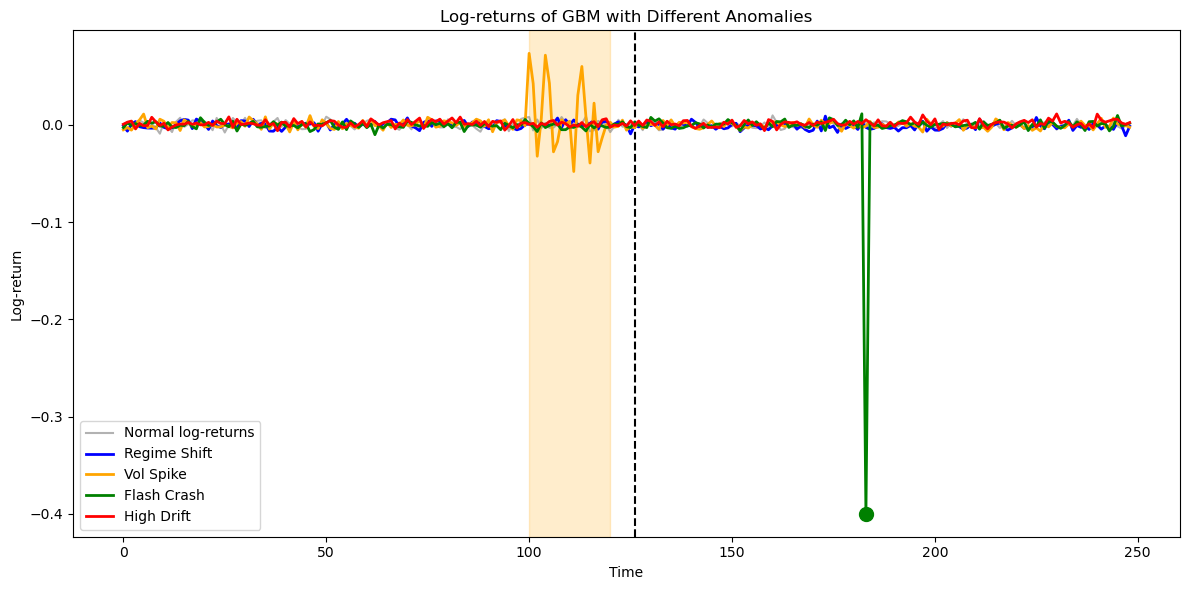

In [21]:
# Pak de dataset
prices_array, labels_array, anomaly_indices, anomaly_info = datasets["mixed_anomaly_set"]

plt.figure(figsize=(12,6))

# Kies een normale reeks
normal_index = 10
S = prices_array[normal_index]
log_returns_normal = np.diff(np.log(S))  # log-returns
plt.plot(log_returns_normal, color="gray", alpha=0.6, label="Normal log-returns")

# Plot anomalieën
color_map = {
    "regime_shift": "blue",
    "vol_spike": "orange",
    "flash_crash": "green",
    "high_drift": "red"
}

for idx in anomaly_indices:
    S = prices_array[idx]
    r = np.diff(np.log(S))  # log-returns
    info = anomaly_info[idx]
    label = info["type"].replace("_", " ").title()
    color = color_map[info["type"]]

    plt.plot(r, linewidth=2, color=color, label=label)

    # Markers
    if info["type"] == "regime_shift":
        plt.axvline(info["break"], linestyle="--", color="black")
    elif info["type"] == "vol_spike":
        plt.axvspan(info["start"], info["end"], alpha=0.2, color=color)
    elif info["type"] == "flash_crash":
        day = info["day"]
        plt.scatter(day-1, r[day-1], color=color, s=100, zorder=5)  # -1 omdat diff de lengte met 1 verkort

plt.title("Log-returns of GBM with Different Anomalies")
plt.xlabel("Time")
plt.ylabel("Log-return")
plt.legend()
plt.tight_layout()
plt.show()

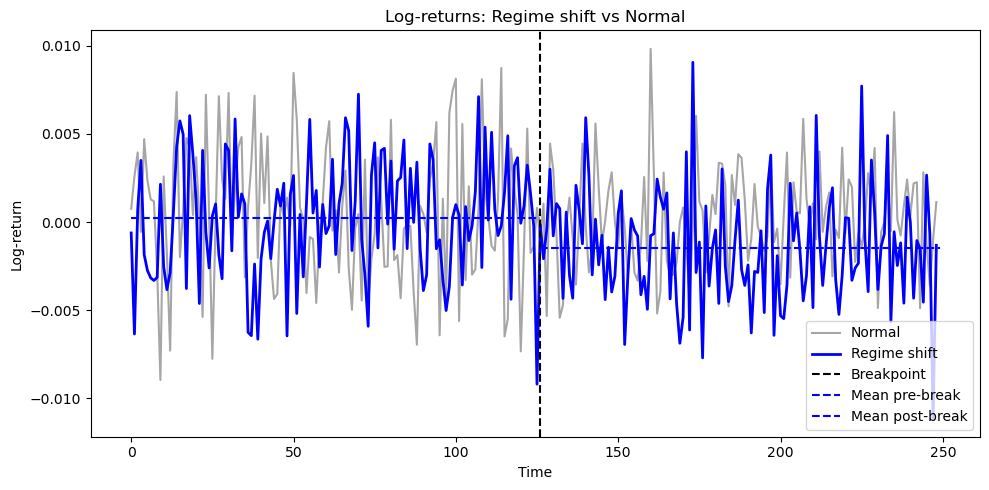

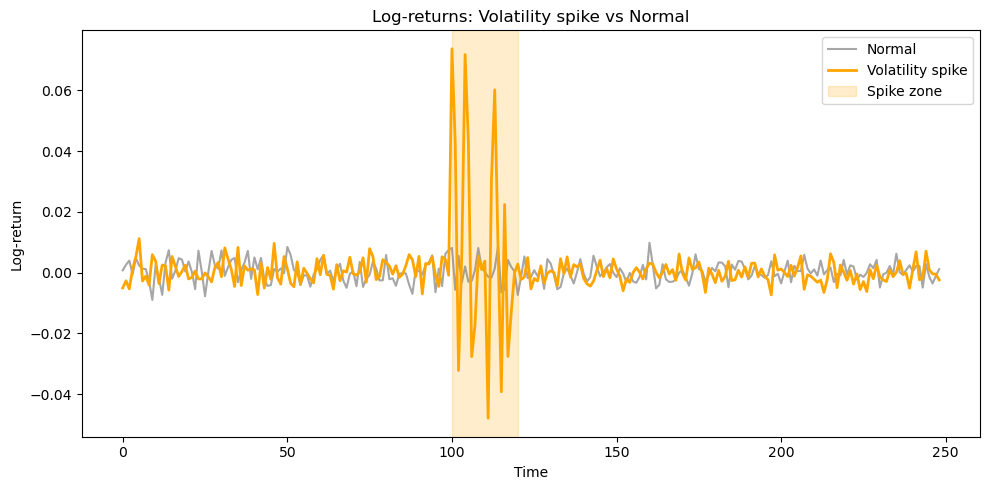

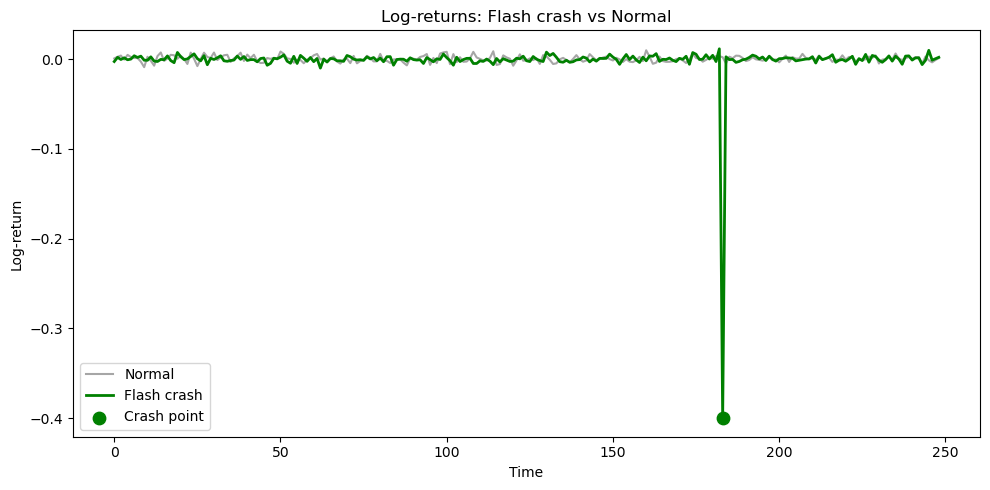

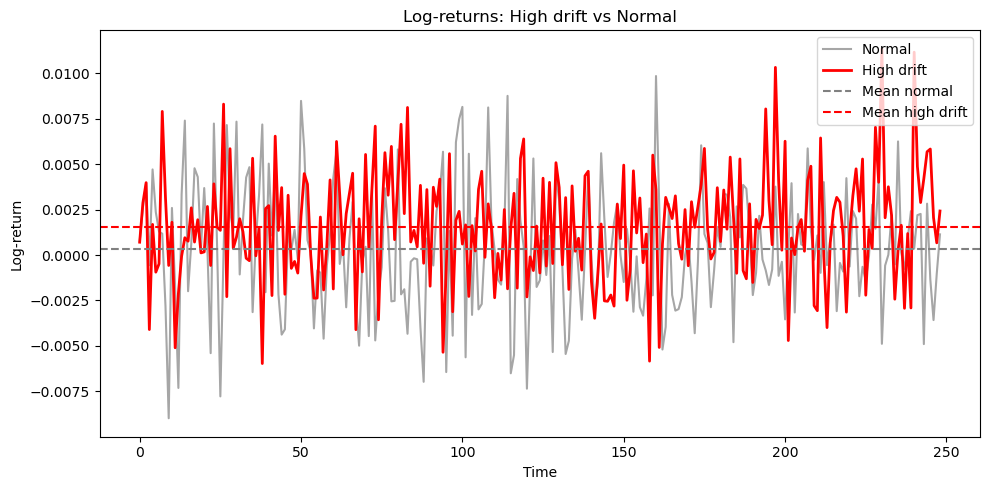

In [22]:
# -----------------------------
# LOG-RETURN PLOTS (geschikt voor dict-structuur)
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt

# Kies dataset
prices_array, labels_array, anomaly_indices, anomaly_info = datasets["mixed_anomaly_set"]

# Kies een vaste normale reeks
normal_index = 10
S_normal = prices_array[normal_index]
normal_returns = np.diff(np.log(S_normal))

# Kleuren
color_normal = "gray"
color_regime = "blue"
color_vol = "orange"
color_flash = "green"
color_drift = "red"

# Loop over alle anomalieën
for idx in anomaly_indices:

    S = prices_array[idx]
    r = np.diff(np.log(S))
    info = anomaly_info[idx]
    anomaly_type = info["type"]  # Let op: dict key

    plt.figure(figsize=(10,5))
    plt.plot(normal_returns, color=color_normal, alpha=0.7, label="Normal")

    # -----------------------------
    # Regime shift
    # -----------------------------
    if anomaly_type == "regime_shift":

        break_point = info["break"]

        plt.plot(r, color=color_regime, linewidth=2, label="Regime shift")
        plt.axvline(break_point, linestyle="--", color="black", label="Breakpoint")

        mean_before = np.mean(r[:break_point])
        mean_after = np.mean(r[break_point:])

        plt.hlines(mean_before, 0, break_point, colors=color_regime,
                   linestyles="--", label="Mean pre-break")
        plt.hlines(mean_after, break_point, len(r),
                   colors=color_regime, linestyles="--",
                   label="Mean post-break")

        plt.title("Log-returns: Regime shift vs Normal")

    # -----------------------------
    # Volatility spike
    # -----------------------------
    elif anomaly_type == "vol_spike":

        spike_start = info["start"]
        spike_end = info["end"]

        plt.plot(r, color=color_vol, linewidth=2, label="Volatility spike")
        plt.axvspan(spike_start, spike_end, alpha=0.2,
                    color=color_vol, label="Spike zone")

        plt.title("Log-returns: Volatility spike vs Normal")

    # -----------------------------
    # Flash crash
    # -----------------------------
    elif anomaly_type == "flash_crash":

        crash_day = info["day"]

        plt.plot(r, color=color_flash, linewidth=2, label="Flash crash")
        plt.scatter(crash_day-1, r[crash_day-1], color=color_flash,
                    s=80, zorder=5, label="Crash point")

        plt.title("Log-returns: Flash crash vs Normal")

    # -----------------------------
    # High drift
    # -----------------------------
    elif anomaly_type == "high_drift":

        plt.plot(r, color=color_drift, linewidth=2, label="High drift")
        plt.axhline(np.mean(normal_returns), color=color_normal,
                    linestyle="--", label="Mean normal")
        plt.axhline(np.mean(r), color=color_drift,
                    linestyle="--", label="Mean high drift")
        plt.title("Log-returns: High drift vs Normal")

    plt.xlabel("Time")
    plt.ylabel("Log-return")
    plt.legend()
    plt.tight_layout()
    plt.show()